# Flight Fare Prediction Using Machine Learning
## AmaliTech NSS - Machine Learning Module Lab

**Objective:** Build an end-to-end ML pipeline for predicting flight fares.

**ML Task:** Supervised Regression
**Target Variable:** Price

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Step 1: Problem Definition & Data Understanding

In [2]:
from src.data_loader import load_dataset, inspect_dataset

df = load_dataset()
summary = inspect_dataset(df)
df.head(10)

INFO | Loading dataset from: C:\Users\DanielAgudeyDoe\Desktop\Lib\Course Projects\Amalitech-Machine-Learning\project\data\raw\Flight_Price_Dataset_of_Bangladesh.csv
INFO | Dataset loaded successfully: 10683 rows, 11 columns
INFO | Inspecting dataset...
INFO | Shape: (10683, 11)
INFO | Data types:
Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object
INFO | Missing values:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64
INFO | Duplicate rows: 220


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [4]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

Missing values per column:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Total duplicate rows: 220


## Step 2: Data Cleaning & Preprocessing
### 2.1 Cleaning the Data

In [6]:
from src.data_cleaning import clean_dataset

df_clean = clean_dataset(df)
print(f"Shape before cleaning: {df.shape}")
print(f"Shape after cleaning:  {df_clean.shape}")
df_clean.head()

INFO | Starting data cleaning. Original shape: (10683, 11)
INFO | Missing values before imputation:
Route          1
Total_Stops    1
dtype: int64
INFO | Imputed 1 missing values in 'Route' with mode
INFO | Imputed 1 missing values in 'Total_Stops' with mode
INFO | Converted 'Price' to float
INFO | Converted 'Date_of_Journey' to datetime
INFO | Removed 220 duplicate rows
INFO | Data cleaning complete. Final shape: (10463, 11)


Shape before cleaning: (10683, 11)
Shape after cleaning:  (10463, 11)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882.0
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218.0
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302.0


In [7]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print(f"\nDuplicate rows: {df_clean.duplicated().sum()}")
print(f"\nData types:")
print(df_clean.dtypes)

Missing values after cleaning:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

Duplicate rows: 0

Data types:
Airline                       str
Date_of_Journey    datetime64[us]
Source                        str
Destination                   str
Route                         str
Dep_Time                      str
Arrival_Time                  str
Duration                      str
Total_Stops                   str
Additional_Info               str
Price                     float64
dtype: object


## Step 3: Exploratory Data Analysis (EDA)
### 3.1 Descriptive Statistics

In [8]:
from src.eda import summarize_fares, compute_kpis

fare_summary = summarize_fares(df_clean)
fare_summary

INFO | Fare summary by airline:
                                       Mean   Median       Std      Min  \
Airline                                                                   
Jet Airways Business               58358.67  54747.0  11667.60  46490.0   
Jet Airways                        11599.02  11134.0   4315.67   1840.0   
Multiple carriers Premium economy  11418.85  11269.0   1717.15   9845.0   
Multiple carriers                  10902.68  10197.0   3721.23   5797.0   
Air India                           9555.38   9292.0   3937.04   2050.0   
Vistara Premium economy             8962.33   9125.0   2915.41   5969.0   
Vistara                             7801.36   7980.0   2915.29   3687.0   
GoAir                               5861.06   5135.0   2703.59   3398.0   
IndiGo                              5668.47   5000.0   2266.93   2227.0   
Air Asia                            5590.26   5162.0   2027.36   3383.0   
SpiceJet                            4335.84   3873.0   1851.14   175

,Mean,Median,Std,Min,Max,Count
Airline,,,,,,
Jet Airways Business,58358.67,54747.0,11667.60,46490.0,79512.0,6
Jet Airways,11599.02,11134.0,4315.67,1840.0,54826.0,3700
Multiple carriers Premium economy,11418.85,11269.0,1717.15,9845.0,14629.0,13
Multiple carriers,10902.68,10197.0,3721.23,5797.0,36983.0,1196
Air India,9555.38,9292.0,3937.04,2050.0,31945.0,1695
Vistara Premium economy,8962.33,9125.0,2915.41,5969.0,11793.0,3
Vistara,7801.36,7980.0,2915.29,3687.0,21730.0,478
GoAir,5861.06,5135.0,2703.59,3398.0,22794.0,194
IndiGo,5668.47,5000.0,2266.93,2227.0,22153.0,2043


In [9]:
kpis = compute_kpis(df_clean)
for key, value in kpis.items():
    print(f"{key}: {value}")

INFO | KPI - avg_fare_per_airline: {'Air Asia': 5590.260188087775, 'Air India': 9555.382890855457, 'GoAir': 5861.056701030928, 'IndiGo': 5668.469897209985, 'Jet Airways': 11599.02108108108, 'Jet Airways Business': 58358.666666666664, 'Multiple carriers': 10902.678093645485, 'Multiple carriers Premium economy': 11418.846153846154, 'SpiceJet': 4335.841717791411, 'Trujet': 4140.0, 'Vistara': 7801.355648535565, 'Vistara Premium economy': 8962.333333333334}
INFO | KPI - most_expensive_airline: Jet Airways Business
INFO | KPI - cheapest_airline: Trujet
INFO | KPI - most_popular_route: DEL -> BOM -> COK
INFO | KPI - popular_route_count: 2377
INFO | KPI - seasonal_variation: {3: 10695.397311426437, 4: 5766.545454545455, 5: 9028.783568904593, 6: 8736.152521896707}
INFO | KPI - peak_month: 3
INFO | KPI - top_5_expensive_routes: {'Banglore -> New Delhi': 12007.421225382932, 'Delhi -> Cochin': 10460.914634146342, 'Kolkata -> Banglore': 9143.083566433566, 'Banglore -> Delhi': 5143.918577075099, 'Mu

avg_fare_per_airline: {'Air Asia': 5590.260188087775, 'Air India': 9555.382890855457, 'GoAir': 5861.056701030928, 'IndiGo': 5668.469897209985, 'Jet Airways': 11599.02108108108, 'Jet Airways Business': 58358.666666666664, 'Multiple carriers': 10902.678093645485, 'Multiple carriers Premium economy': 11418.846153846154, 'SpiceJet': 4335.841717791411, 'Trujet': 4140.0, 'Vistara': 7801.355648535565, 'Vistara Premium economy': 8962.333333333334}
most_expensive_airline: Jet Airways Business
cheapest_airline: Trujet
most_popular_route: DEL → BOM → COK
popular_route_count: 2377
seasonal_variation: {3: 10695.397311426437, 4: 5766.545454545455, 5: 9028.783568904593, 6: 8736.152521896707}
peak_month: 3
top_5_expensive_routes: {'Banglore -> New Delhi': 12007.421225382932, 'Delhi -> Cochin': 10460.914634146342, 'Kolkata -> Banglore': 9143.083566433566, 'Banglore -> Delhi': 5143.918577075099, 'Mumbai -> Hyderabad': 5059.708751793401}


### 3.2 Visual Analysis

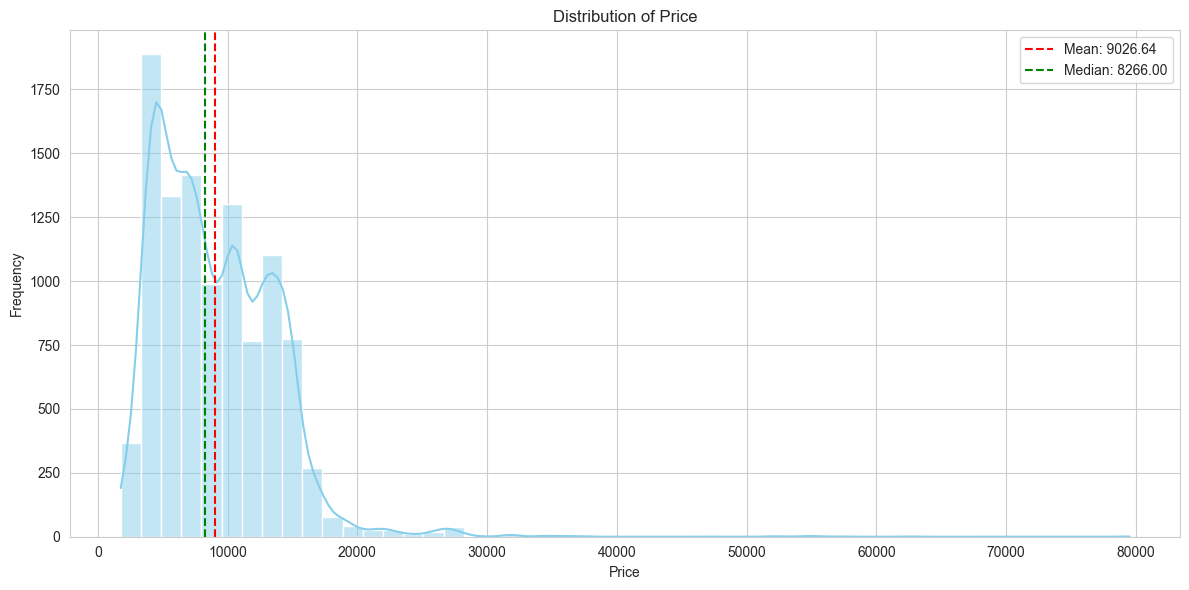

INFO | Fare distribution plotted. Mean: 9026.64, Median: 8266.00


In [10]:
from src.eda import plot_fare_distribution
plot_fare_distribution(df_clean)

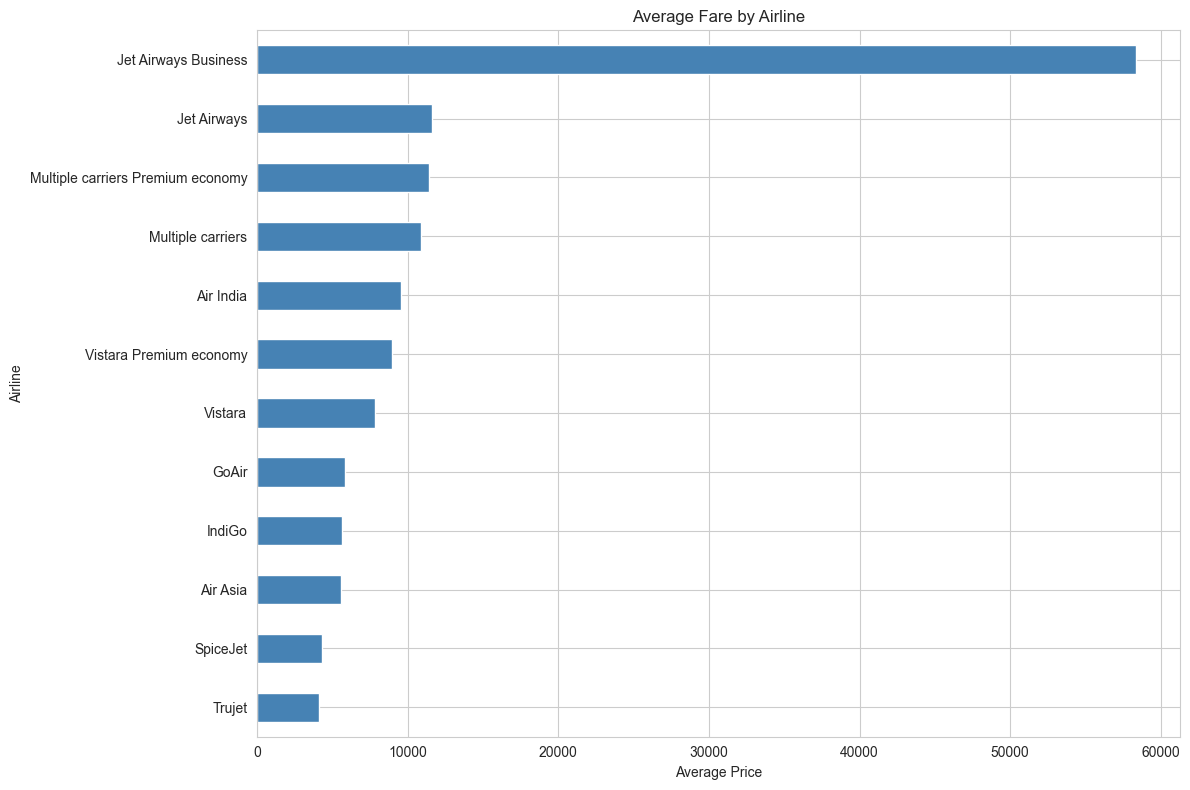

INFO | Highest avg fare: Jet Airways Business at 58358.67


In [11]:
from src.eda import plot_fare_by_airline
plot_fare_by_airline(df_clean)

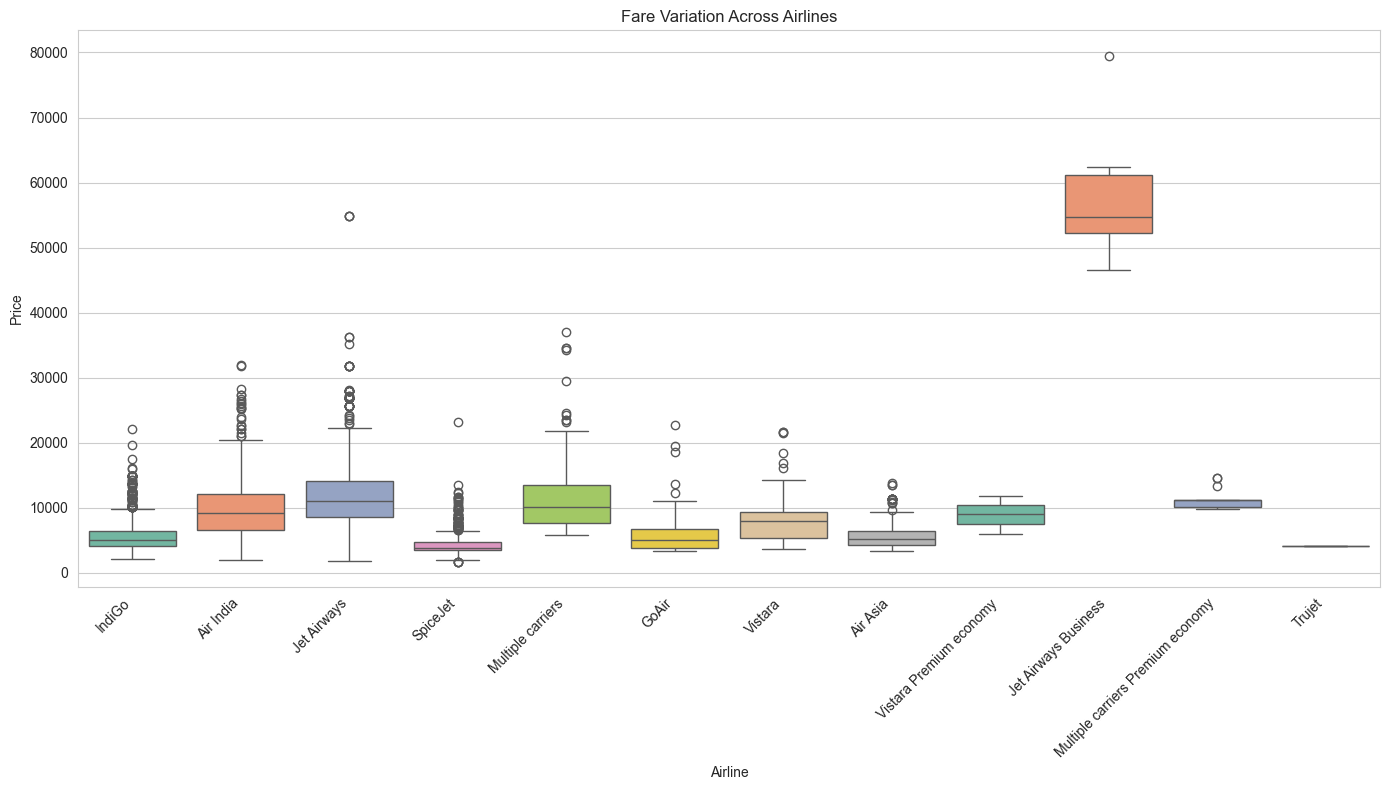

In [12]:
from src.eda import plot_fare_boxplots
plot_fare_boxplots(df_clean)

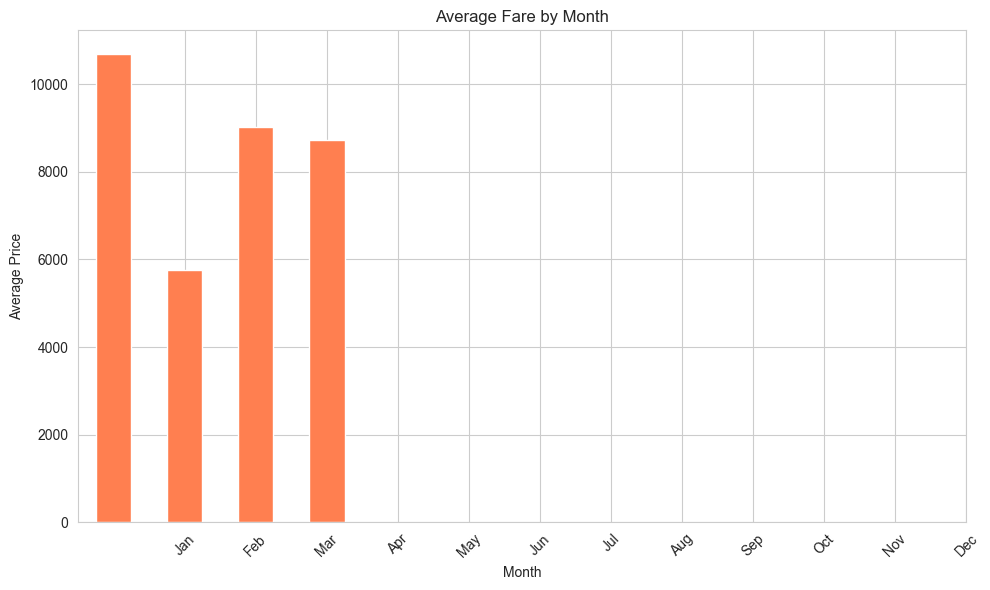

INFO | Seasonal fare variation plotted. Highest month: 3 at 10695.40


In [13]:
from src.eda import plot_fare_by_season
plot_fare_by_season(df_clean)

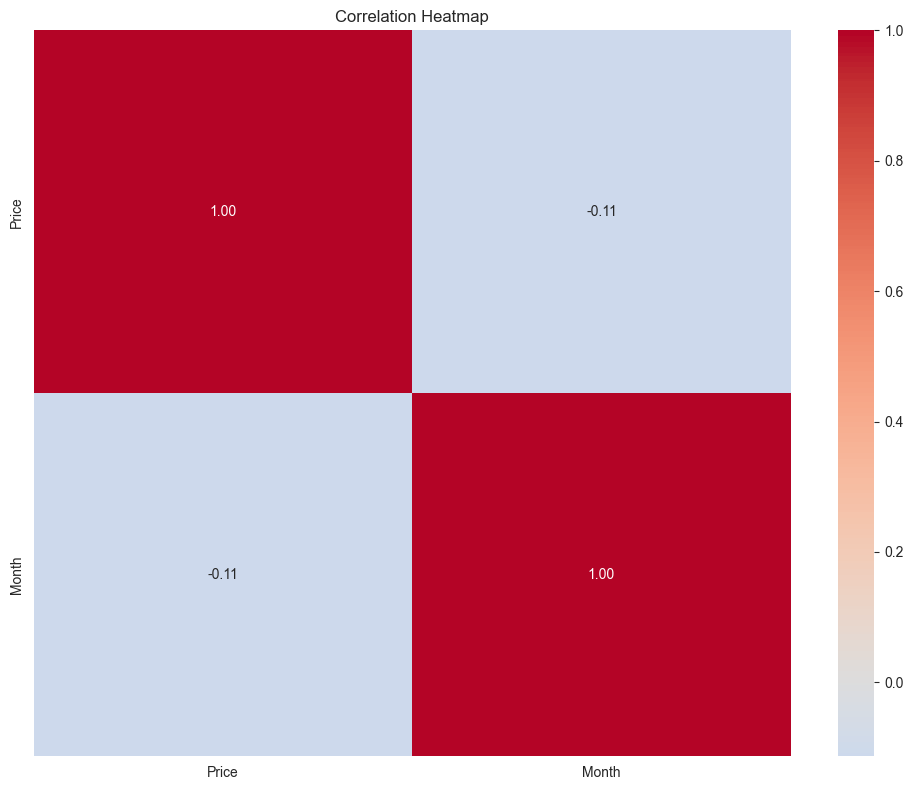

In [14]:
from src.eda import plot_correlation_heatmap
plot_correlation_heatmap(df_clean)

### 3.3 Key EDA Findings
- (Agent fills these in after running the plots and analyzing results)
- Average fare per airline: ...
- Most popular route: ...
- Seasonal patterns: ...
- Top 5 most expensive routes: ...
- Notable correlations: ...

## Step 4: Feature Engineering
### 4.1 Feature Creation & Encoding

In [ ]:
from src.feature_engineering import run_feature_pipeline

X_train, X_test, y_train, y_test, scaler, feature_names = run_feature_pipeline(
    df_clean, target_col='Price'
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Features:     {len(feature_names)}")
print(f"\nFeature names: {feature_names[:10]}...")

In [ ]:
print("Target variable (y_train) statistics:")
print(y_train.describe())
print(f"\nNaN values in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN values in X_test: {X_test.isnull().sum().sum()}")